# NAME : SHARVAN KOTHARU
# ROLL : 01  
# SEC : A3  
# ML LAB 3 : LINEAR REGRESSION ALGO ON HOUSE PRICE PREDICTION (DATASET)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error
from sklearn.model_selection import GridSearchCV

In [3]:
df=pd.read_csv('/content/Housing.csv')

In [4]:
# perform EDA
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.shape

(545, 13)

In [10]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [11]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [13]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [23]:
# perform one hot encoding

df_encoded = pd.get_dummies(df, drop_first=True,dtype=int)
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


<Figure size 1200x800 with 0 Axes>

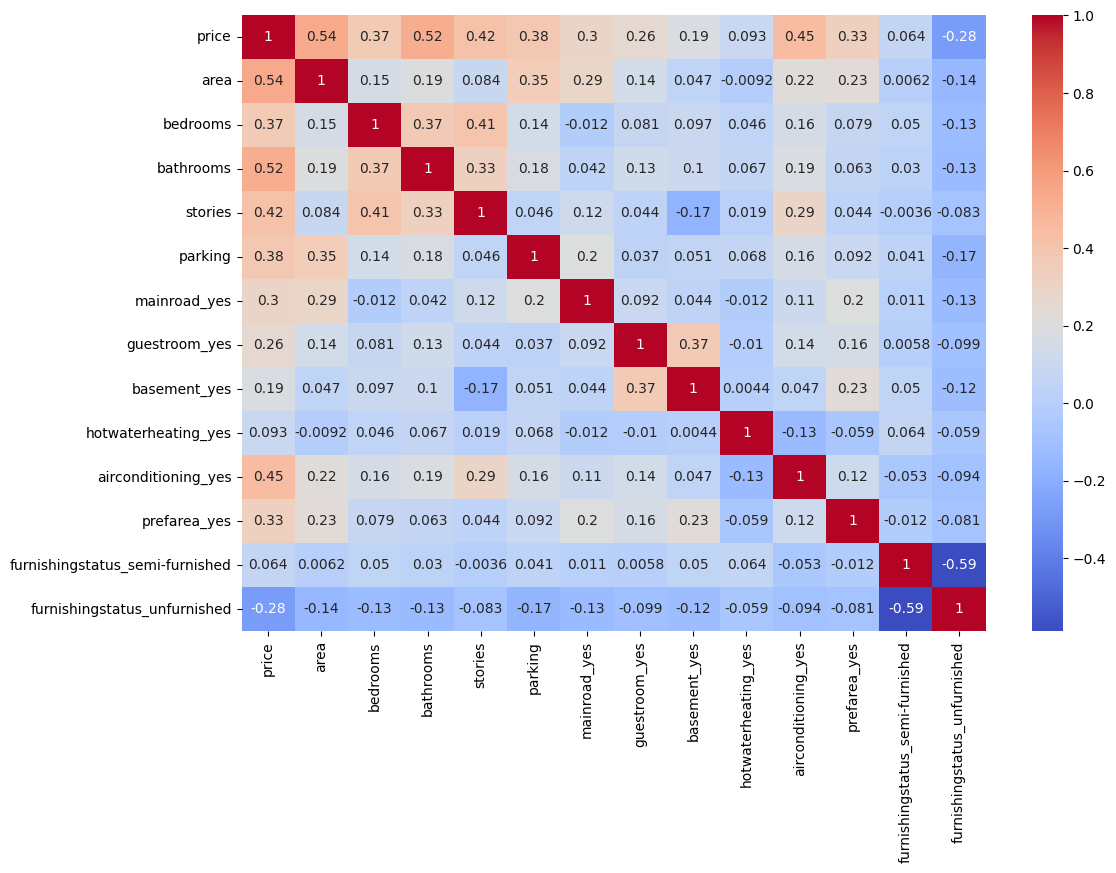

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.show()

# Using feature selection we can identify that price is the target in this dataset  
# Realistically speaking , the price does'nt depend on hotwater_heating so we can drop that colm

In [45]:
df_encoded=df_encoded.drop(columns=['hotwaterheating'])

KeyError: "['hotwaterheating'] not found in axis"

In [46]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


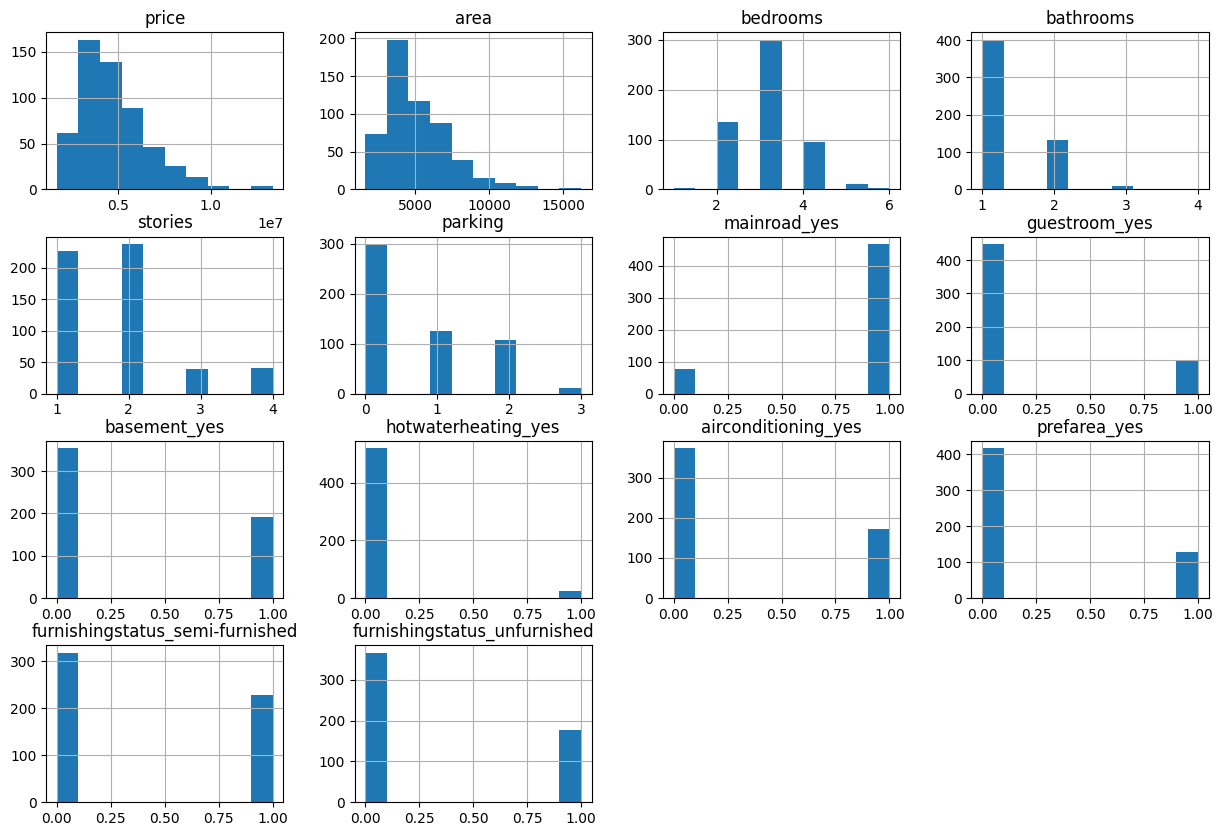

In [47]:
df_encoded.hist(figsize=(15,10))
plt.show()

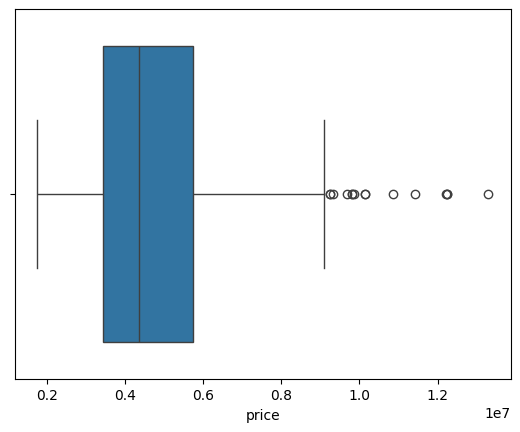

In [48]:
sns.boxplot(x=df_encoded['price']) # outliers
plt.show()

In [35]:
# Linear Regression

In [53]:
X=df_encoded.drop("price",axis=1)
Y=df_encoded["price"]

In [54]:
X_train, X_test, y_train, y_test = train_test_split( X,Y,test_size=0.2,random_state=42)

In [64]:
y_test.shape

(109,)

In [55]:
lr= LinearRegression()

In [56]:
lr.fit(X_train,y_train)

LinearRegression()

In [58]:
y_pred = lr.predict(X_test)

In [59]:
# model parameters

In [60]:
mse = mean_squared_error(y_test, y_pred)
print("MSE =", mse)
rmse = np.sqrt(mse)
print("RMSE =", rmse)
r2 = r2_score(y_test, y_pred)
print("R2 Score =", r2)

MSE = 1754318687330.6638
RMSE = 1324506.9600914386
R2 Score = 0.6529242642153184


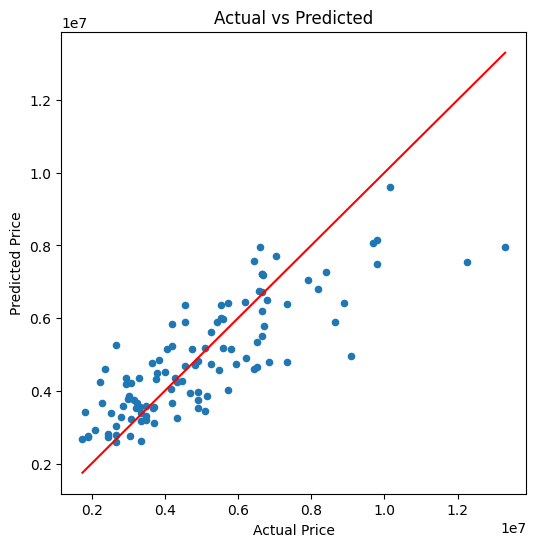

In [62]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, s=20)

plt.plot(
    [Y.min(), Y.max()],
    [Y.min(), Y.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [66]:
# Hyperparmeter Tuning

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

In [69]:
params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

In [70]:
lr = LinearRegression()

grid = GridSearchCV(
    estimator=lr,
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

In [71]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'fit_intercept': True, 'positive': False}
Best Cross Validation Score: 0.6470401792343203


In [72]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [74]:
mse = mean_squared_error(y_test, y_pred)
print("MSE =", mse)
rmse = np.sqrt(mse)
print("RMSE =", rmse)
r2 = r2_score(y_test, y_pred)
print("R2 Score =", r2)

MSE = 1754318687330.6638
RMSE = 1324506.9600914386
R2 Score = 0.6529242642153184
